# SETUP

**COLAB SETUP**
- import your branch
- your changes have to be on Github, meaning you have to push your branch
- put the data somewhere in Google or have a script to download it at runtime

In [ ]:
!pip install git+https://github.com/lucas-nunn/PSM-NeuroAI-Final.git@YOUR_BRANCH_NAME_HERE

from google.colab import drive
drive.mount('/content/drive/', force_remount=True)
main_dir = '/content/drive/MyDrive/UvA_encodingtutorial'
fmri_dir = os.path.join(main_dir, 'fmri_data')

# Make sure that the data directory is accessible
assert os.path.isdir(main_dir)

# this should show the directory's content, looking like this:
#['/content/drive/MyDrive/UvA_encodingtutorial/fmri_data/subj01',
# '/content/drive/MyDrive/UvA_encodingtutorial/fmri_data/subj02',
# '/content/drive/MyDrive/UvA_encodingtutorial/fmri_data/subj03',
# etc.
glob(fmri_dir+'/*')

In [5]:
# import some libraries
import os
import torch
import torchvision                        # Torch stuff for Computer vision
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
    
# import from our beautiful package
from psm_final.helpers.MLP import SimpleMLP
from psm_final.helpers.plotting import plot_dataset_samples
from psm_final.helpers.training_testing import train_and_test

# put stuff in the right place
DATA_DIR = "../data"
RESULTS_DIR = "../results"
FIGURES_DIR = "../figures"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# DO SOMETHING

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5586283].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7147107].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.6756902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.6171591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.2854843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.6756902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.429065

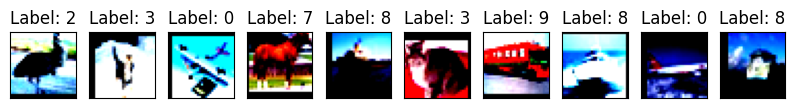

In [3]:
# Get CIFAR10 training and testing datasets from torch
# Define transforms for data normalization and augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))  # CIFAR-10 mean and std
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load CIFAR-10 dataset
cifar10_train = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform_train)
cifar10_test = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform_test)

# Create DataLoaders
batch_size = 128
cifar_dataloader_train = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True, num_workers=2)
cifar_dataloader_test = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False, num_workers=2)

# plot dataset samples
plot_dataset_samples(cifar_dataloader_train, 10)

In [4]:
# Create an instance of the model
cifar_simpleMLP = SimpleMLP(n_input_pixels=32*32*3, n_hidden=32)
# Move the model to the desired device
cifar_simpleMLP = cifar_simpleMLP.to(device)

cifar_criterion = nn.CrossEntropyLoss()  # Standardly used for classification
cifar_optimizer = torch.optim.Adam(cifar_simpleMLP.parameters(), lr=0.001)

history = train_and_test(cifar_simpleMLP, cifar_dataloader_train, cifar_dataloader_test, 5, cifar_criterion, cifar_optimizer, device)

Epoch 1/5


Epoch 1:   2%|▏         | 6/391 [00:00<00:06, 59.51it/s]

Batch Loss: 2.2222096920013428

Epoch 1:   5%|▍         | 18/391 [00:00<00:04, 92.92it/s]

Batch Loss: 2.186427354812622

...

Batch Loss: 2.0911514759063725

Epoch 5:  98%|█████████▊| 385/391 [00:03<00:00, 124.04it/s]

Batch Loss: 2.1271338462829593

100%|██████████| 79/79 [00:00<00:00, 181.71it/s]

Test Loss: 2.0500, Accuracy: 40.69%


# SAVE YOUR RESULTS

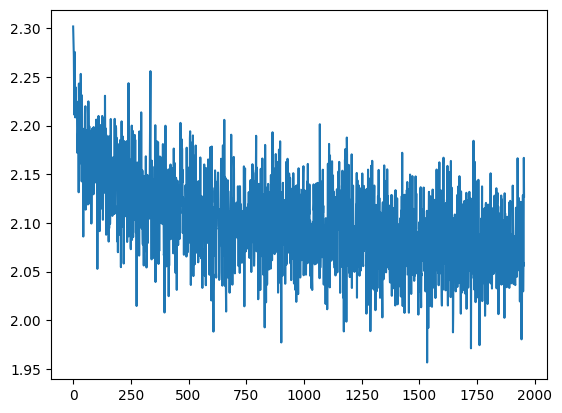

In [6]:

plt.plot(history)
plt.savefig(os.path.join(FIGURES_DIR, 'dev101.png'))